In [1]:
import yfinance as yf
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import time

start = time.time()

In [2]:
UROY = yf.download("UROY", start = "2021-05-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
UROY.shape

(1321, 5)

In [4]:
UROY.describe()

Price,Close,High,Low,Open,Volume
Ticker,UROY,UROY,UROY,UROY,UROY
count,1321.000000,1321.000000,1321.000000,1321.000000,1.321000e+03
mean,2.908053,3.002412,2.816871,2.920295,1.587168e+06
std,0.806421,0.847767,0.760989,0.812158,1.694880e+06
min,1.470000,1.610000,1.430000,1.470000,4.580000e+04
25%,2.340000,2.390000,2.285000,2.350000,5.058000e+05
50%,2.670000,2.757000,2.600000,2.690000,1.114100e+06
75%,3.400000,3.530000,3.280000,3.410000,2.177300e+06
max,5.780000,5.950000,5.500000,5.730000,2.320040e+07


In [5]:
returns = UROY["Close"].pct_change().dropna()

In [6]:
daily_std = returns.std()

In [7]:
sigma = daily_std * np.sqrt(252)

In [8]:
print(sigma)

Ticker
UROY    0.704743
dtype: float64


In [9]:
S0 = 3.52
K = 3.5 
r = 0.038
sigma = 0.704278
T = 30/252 
n_steps = 30 
n_simulations = 100000

In [10]:
dt = T/n_steps

In [11]:
np.random.normal()

-2.1363387384304473

In [12]:
Z = np.random.normal(size = (n_simulations, n_steps))

Z.shape

(100000, 30)

In [13]:

log_returns = (r - 0.5 *sigma**2)*dt + sigma*np.sqrt(dt)*Z

log_returns.shape

(100000, 30)

In [14]:
cumulative_log_returns = np.cumsum(log_returns, axis = 1)

In [15]:
price_paths = S0 * np.exp(cumulative_log_returns)

In [16]:
price_paths.shape

(100000, 30)

In [17]:
print(len(price_paths))

100000


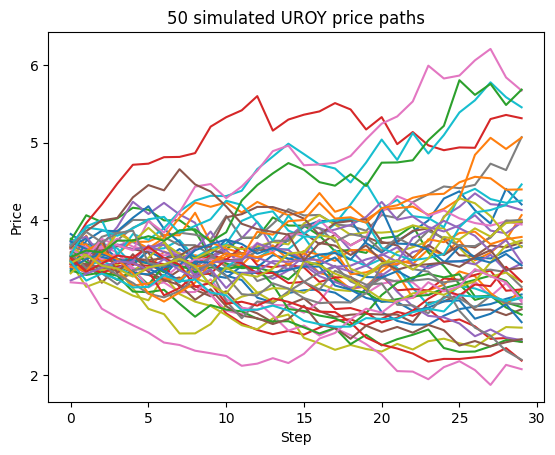

In [18]:
plt.plot(price_paths[:50].T)
plt.title("50 simulated UROY price paths")
plt.xlabel("Step") 
plt.ylabel("Price")
plt.show()

In [19]:
final_prices = price_paths[:,-1] 

In [20]:
len(final_prices)

100000

In [21]:
final_prices[:5]

array([3.04335624, 4.06625964, 2.87969598, 2.43152115, 4.13168822])

In [22]:
print(S0)

3.52


In [23]:
payoffs = np.maximum(final_prices - K, 0) 

In [24]:
print(payoffs[:10])

[0.         0.56625964 0.         0.         0.63168822 0.
 0.         1.57049099 0.         0.        ]


In [25]:
payoffs.mean()

np.float64(0.3563424363732528)

In [26]:
(payoffs > 0).sum()

np.int64(46462)

In [27]:
average_payoff = payoffs.mean()

In [28]:
option_prices = np.exp(-r*T) * average_payoff

In [29]:
print(option_prices)

0.3547340518214718


In [30]:
from scipy.stats import norm 

In [31]:
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

In [32]:
d2 = d1 - sigma*np.sqrt(T)

In [33]:
call_price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

In [34]:
print(call_price)

0.35686615820677803


In [35]:
end = time.time()
print(f"This version: {end - start:.3f} seconds")

Vector version: 5.291 seconds
